## This notebook is used to reproduce the results in 4.4

[mixed_aes] | analyze_time=6.709s | ok=True
  L_full=80000, occs=47
  [EVAL] Hit Rate: 100.00% (47/47)


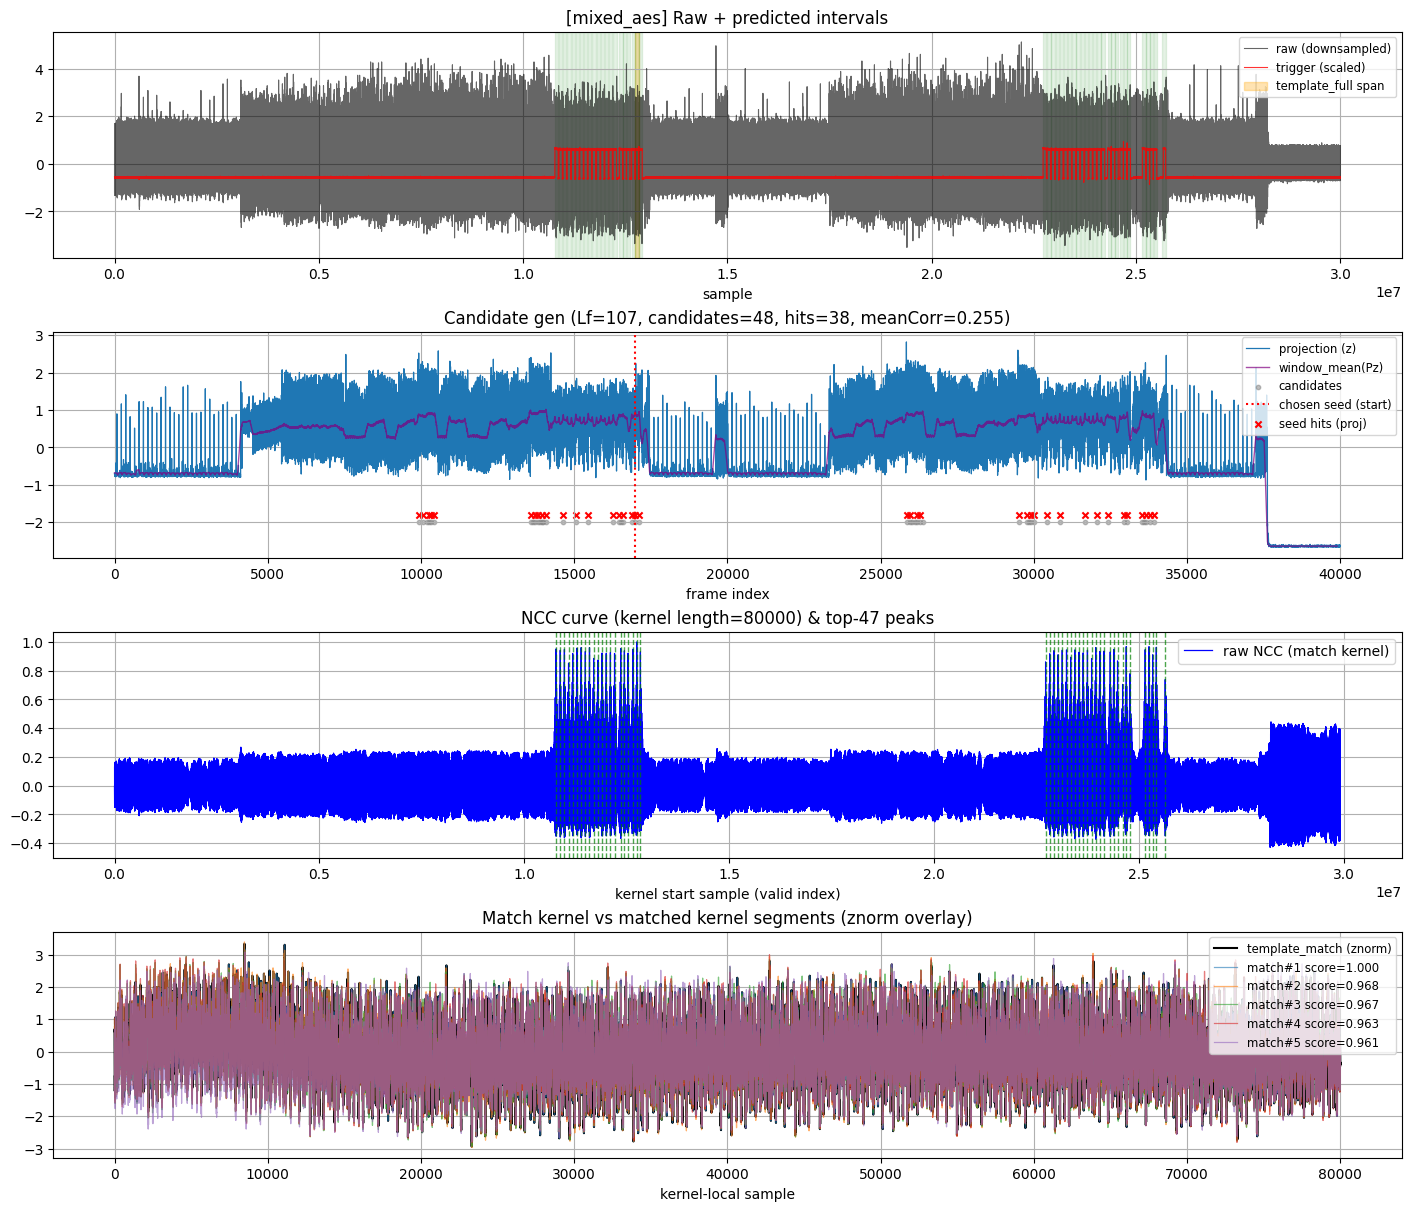

[mixed_sha256] | analyze_time=6.482s | ok=True
  L_full=450000, occs=16
  [EVAL] Hit Rate: 100.00% (16/16)


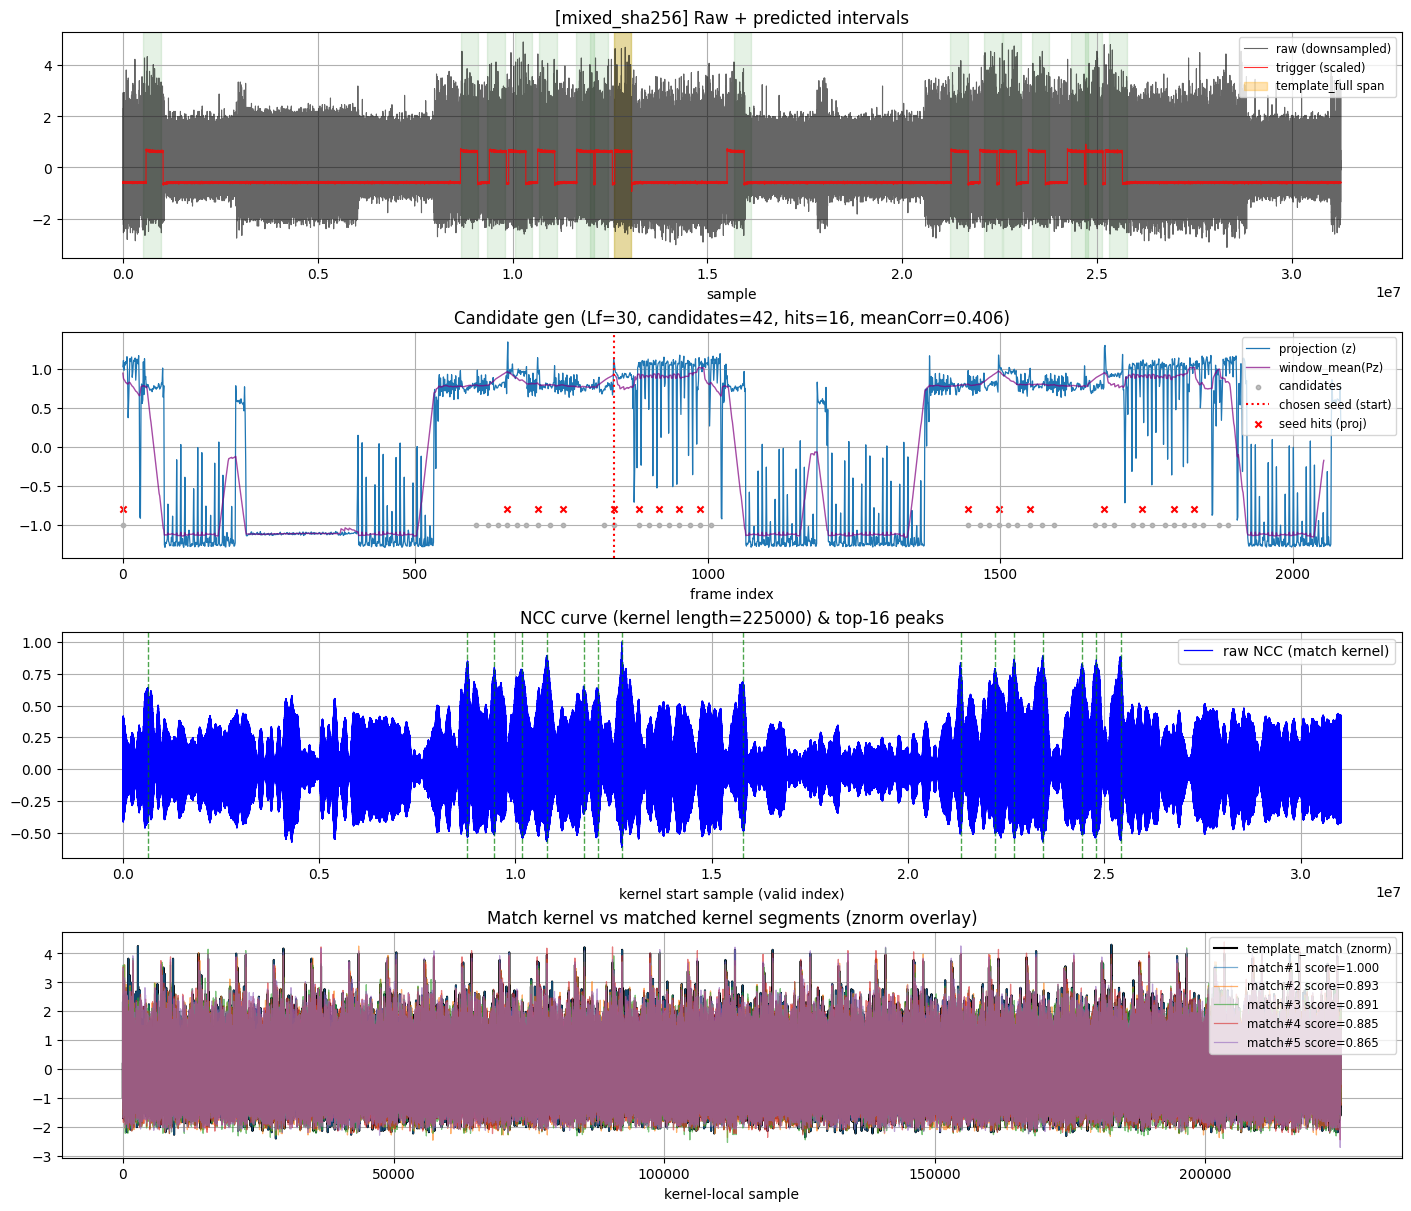

In [4]:
import os
import sys
sys.path.append(os.path.abspath(''))
from src.motif import *
import numpy as np
import random
import time
import dataclasses
import pandas as pd

# for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

fs = 100.0e6
trigger_threshold=0.5
noise_std = 0.0


configs = [
    DatasetConfig(
        name="mixed_aes",
        signal_path="dataset/semi-loc/arm-m4-48MHz/np_power.npy",
        trigger_path="dataset/semi-loc/arm-m4-48MHz/np_trigger.npy",
        window=1000,
        target_length_points=80000,
        target_count=47,

        fs=fs,
        noise_std=noise_std,
        trigger_threshold=trigger_threshold,
        
    ),
    DatasetConfig(
        name="mixed_sha256",
        signal_path="dataset/semi-loc/sha/sha256_48_power.npy",
        trigger_path="dataset/semi-loc/sha/sha256_48_trigger.npy",
        window=20000,
        target_length_points=450000,
        target_count=16,
        center=0.5,

        fs=fs,
        noise_std=noise_std,
        trigger_threshold=trigger_threshold,
    ),
]

for cfg in configs:

    # Analyze (the time you said you want to count)
    t0 = time.perf_counter()
    signal_data, trig, _ = load_data(cfg)
    res = gated_search_pipeline(signal_data, cfg)
    t_analyze = time.perf_counter() - t0

    # Evaluate / Plot / Save (excluded from analyze time)
    ev = evaluate(cfg, trig, res)
    summary = save(cfg, res, ev)
    # Print
    print(f"[{cfg.name}] | analyze_time={t_analyze:.3f}s | ok={summary['ok']}")
    if summary["ok"]:
        print(f"  L_full={summary['L_full']}, occs={len(summary['occurrences_full'])}")
        if summary.get("eval_gt_count", -1) > 0:
            print(f"  [EVAL] Hit Rate: {summary['eval_hit_rate']:.2%} ({summary['eval_hits']}/{summary['eval_gt_count']})")
        else:
            print("  [EVAL] No trigger data or no GT events.")
    else:
        print(f"  reason: {summary.get('reason','unknown')}")
    
    plot(cfg, signal_data, trig, res)
    

In [2]:
import dataclasses
import hashlib
import random
import numpy as np
import pandas as pd

noise_std_list = [0.5, 1.0, 2.0, 3.0, 5.0]
N_REPEAT = 2
SEED = 42

results_noise = []

def derive_seed(base_seed: int, dataset_name: str, noise_std: float, rep: int) -> int:
    msg = f"{base_seed}|{dataset_name}|{noise_std:.10g}|{rep}".encode("utf-8")
    digest = hashlib.blake2b(msg, digest_size=8).digest()  # 64-bit
    return int.from_bytes(digest, "little") & 0xFFFFFFFF  # 32-bit for numpy/random

print(f"{'='*20} Noise Test {'='*20}")

for std in noise_std_list:
    print(f"\n--- Testing Noise Std: {std} ---")

    for base_cfg in configs:
        for rep in range(N_REPEAT):

            run_seed = derive_seed(SEED, base_cfg.name, std, rep)
            np.random.seed(run_seed)
            random.seed(run_seed)

            current_cfg = dataclasses.replace(base_cfg, noise_std=std)

            try:
                # Run Analysis
                signal_data, trig, _ = load_data(current_cfg, rng_seed=run_seed)
                res = gated_search_pipeline(signal_data, current_cfg)
                ev = evaluate(current_cfg, trig, res)
                summary = save(current_cfg, res, ev)

                hit_rate = summary["eval_hit_rate"]
                print(f"Dataset: {base_cfg.name:<20} | Rep: {rep:02d} | Seed: {run_seed:<10} | Hit Rate: {hit_rate:.2%}")

                results_noise.append({
                    "Dataset": base_cfg.name,
                    "Noise_Std": std,
                    "Repeat": rep,
                    "Seed": run_seed,
                    "Hit_Rate": hit_rate
                })

            except Exception as e:
                print(f"Dataset: {base_cfg.name:<20} | Rep: {rep:02d} | Seed: {run_seed:<10} | Error: {e}")
                results_noise.append({
                    "Dataset": base_cfg.name,
                    "Noise_Std": std,
                    "Repeat": rep,
                    "Seed": run_seed,
                    "Hit_Rate": -1.0
                })

print(f"\n{'='*20} Result {'='*20}")

df_noise = pd.DataFrame(results_noise)

pivot_noise_rep = df_noise.pivot_table(
    index=["Dataset", "Repeat"],
    columns="Noise_Std",
    values="Hit_Rate",
    aggfunc="first"
).sort_index()

print("\n--- Per-repeat (Dataset, Repeat) x Noise_Std ---")
print(pivot_noise_rep.applymap(lambda x: f"{x:.2%}" if x >= 0 else "Error"))

agg = (df_noise[df_noise["Hit_Rate"] >= 0]
       .groupby(["Dataset", "Noise_Std"])["Hit_Rate"]
       .agg(["mean", "std", "count"])
       .reset_index())

pivot_mean = agg.pivot(index="Dataset", columns="Noise_Std", values="mean")
pivot_std  = agg.pivot(index="Dataset", columns="Noise_Std", values="std")

print("\n--- Mean Hit Rate ---")
print(pivot_mean.applymap(lambda x: f"{x:.2%}" if pd.notna(x) else "NA"))

print("\n--- Std Hit Rate ---")
print(pivot_std.applymap(lambda x: f"{x:.2%}" if pd.notna(x) else "NA"))


==================== Noise Test ====================

--- Testing Noise Std: 0.5 ---
Dataset: mixed_aes            | Rep: 00 | Seed: 634561974  | Hit Rate: 100.00%
Dataset: mixed_aes            | Rep: 01 | Seed: 546357500  | Hit Rate: 100.00%
Dataset: mixed_sha256         | Rep: 00 | Seed: 3236735566 | Hit Rate: 100.00%
Dataset: mixed_sha256         | Rep: 01 | Seed: 4197292048 | Hit Rate: 100.00%

--- Testing Noise Std: 1.0 ---
Dataset: mixed_aes            | Rep: 00 | Seed: 2284207775 | Hit Rate: 100.00%
Dataset: mixed_aes            | Rep: 01 | Seed: 1334984750 | Hit Rate: 100.00%
Dataset: mixed_sha256         | Rep: 00 | Seed: 1301399612 | Hit Rate: 100.00%
Dataset: mixed_sha256         | Rep: 01 | Seed: 3859778496 | Hit Rate: 31.25%

--- Testing Noise Std: 2.0 ---
Dataset: mixed_aes            | Rep: 00 | Seed: 2190490476 | Hit Rate: 0.00%
Dataset: mixed_aes            | Rep: 01 | Seed: 3658619442 | Hit Rate: 0.00%
Dataset: mixed_sha256         | Rep: 00 | Seed: 1910961677 | Hit R

/var/folders/f8/jsfljvz136v32ls7xnpds8lh0000gn/T/ipykernel_84981/1142315651.py:72: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(pivot_noise_rep.applymap(lambda x: f"{x:.2%}" if x >= 0 else "Error"))
/var/folders/f8/jsfljvz136v32ls7xnpds8lh0000gn/T/ipykernel_84981/1142315651.py:83: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(pivot_mean.applymap(lambda x: f"{x:.2%}" if pd.notna(x) else "NA"))
/var/folders/f8/jsfljvz136v32ls7xnpds8lh0000gn/T/ipykernel_84981/1142315651.py:86: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(pivot_std.applymap(lambda x: f"{x:.2%}" if pd.notna(x) else "NA"))


In [19]:


length_win_list = [1000, 5000, 10000, 15000, 20000]
seed_value = 42
results_length = []
SEED = 42
np.random.seed(SEED)
random.seed(SEED)


print(f"{'='*20} Window Test {'='*20}")

for win in length_win_list:
    
    print(f"\n--- Testing Window: {win} ---")
    
    for base_cfg in configs:

        current_cfg = dataclasses.replace(base_cfg, window=win)

        try:
            # Run Analysis
            signal_data, trig, _ = load_data(current_cfg)
            res = gated_search_pipeline(signal_data, current_cfg)
            ev = evaluate(current_cfg, trig, res)
            summary = save(current_cfg, res, ev)
            
            hit_rate = summary['eval_hit_rate']
            print(f"Dataset: {base_cfg.name:<20} | Win: {win:<8} | Hit Rate: {hit_rate:.2%}")
            
            results_length.append({
                "Dataset": base_cfg.name,
                "Win": win,
                "Hit_Rate": hit_rate
            })
            
        except Exception as e:
            print(f"Dataset: {base_cfg.name:<20} | Error: {e}")
            results_length.append({
                "Dataset": base_cfg.name,
                "Win": win,
                "Hit_Rate": -1.0
            })

print(f"\n{'='*20} Result {'='*20}")
df_length = pd.DataFrame(results_length)
pivot_length = df_length.pivot(index="Dataset", columns="Win", values="Hit_Rate")
print(pivot_length.applymap(lambda x: f"{x:.2%}" if x >= 0 else "Error"))

==================== Window Test ====================

--- Testing Window: 1000 ---
Dataset: mixed_aes            | Win: 1000     | Hit Rate: 100.00%
Dataset: mixed_sha256         | Win: 1000     | Hit Rate: 25.00%

--- Testing Window: 2000 ---
Dataset: mixed_aes            | Win: 2000     | Hit Rate: 100.00%
Dataset: mixed_sha256         | Win: 2000     | Hit Rate: 18.75%

--- Testing Window: 5000 ---
Dataset: mixed_aes            | Win: 5000     | Hit Rate: 0.00%
Dataset: mixed_sha256         | Win: 5000     | Hit Rate: 100.00%

--- Testing Window: 10000 ---
Dataset: mixed_aes            | Win: 10000    | Hit Rate: 0.00%
Dataset: mixed_sha256         | Win: 10000    | Hit Rate: 31.25%

--- Testing Window: 15000 ---
Dataset: mixed_aes            | Win: 15000    | Hit Rate: 0.00%
Dataset: mixed_sha256         | Win: 15000    | Hit Rate: 100.00%

--- Testing Window: 20000 ---
Dataset: mixed_aes            | Win: 20000    | Hit Rate: 0.00%
Dataset: mixed_sha256         | Win: 20000    | 

/var/folders/f8/jsfljvz136v32ls7xnpds8lh0000gn/T/ipykernel_84124/3200962913.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(pivot_length.applymap(lambda x: f"{x:.2%}" if x >= 0 else "Error"))
